In [1]:
# import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# import file
# remember to put r in front of file path
df = pd.read_csv(r"C:\Users\wjlee\Desktop\Data Projects\COE Prices\COEBiddingResultsPrices - MySQL Cleaned.csv") 

In [8]:
# inspect table
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   bidding_no     1776 non-null   int64 
 1   vehicle_class  1776 non-null   object
 2   quota          1776 non-null   int64 
 3   bids_success   1776 non-null   int64 
 4   bids_received  1776 non-null   int64 
 5   premium        1776 non-null   int64 
 6   year           1776 non-null   int64 
 7   month          1776 non-null   int64 
 8   YrMth          1776 non-null   object
dtypes: int64(7), object(2)
memory usage: 125.0+ KB


In [10]:
# YrMth col is still object/string. need to convert to date type
df['YrMth'] = pd.to_datetime(df['YrMth'])

In [12]:
# inspect table again
# no null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   bidding_no     1776 non-null   int64         
 1   vehicle_class  1776 non-null   object        
 2   quota          1776 non-null   int64         
 3   bids_success   1776 non-null   int64         
 4   bids_received  1776 non-null   int64         
 5   premium        1776 non-null   int64         
 6   year           1776 non-null   int64         
 7   month          1776 non-null   int64         
 8   YrMth          1776 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 125.0+ KB


In [51]:
# group by year to find out total number of quota by year
total_quota_by_year = df.groupby('year')['quota'].sum()
total_quota_by_year

year
2010     54927
2011     45566
2012     42942
2013     40866
2014     44585
2015     75115
2016    105103
2017    112266
2018    108772
2019     97291
2020     61044
2021     62275
2022     43257
2023     40756
2024     29171
2025     17893
Name: quota, dtype: int64

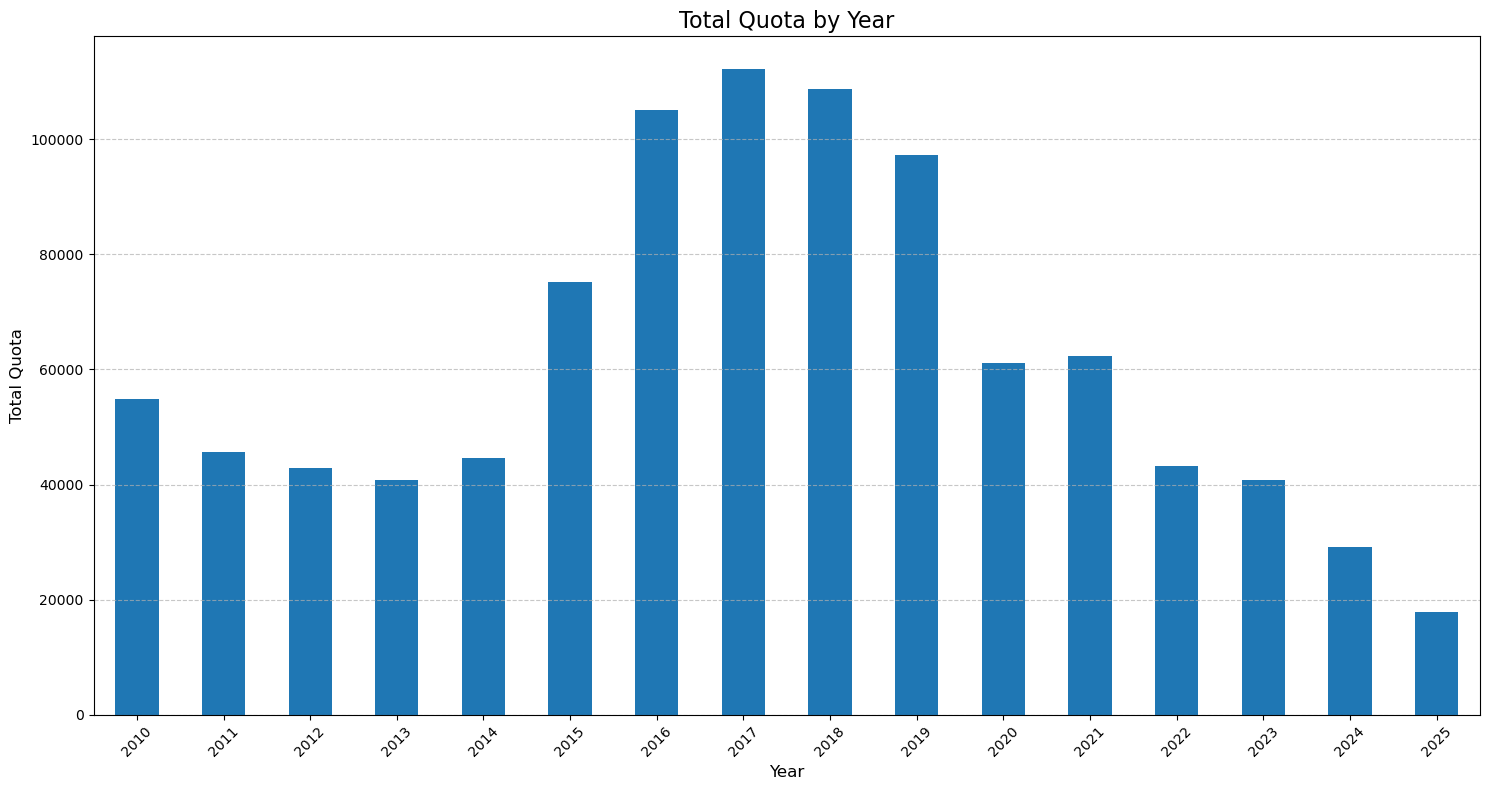

In [55]:
# Create the bar chart directly from the result
plt.figure(figsize=(15, 8))
total_quota_by_year.plot(kind='bar')

# Config bar chart: Set the title and labels
plt.title('Total Quota by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Quota', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# abv chart shows the period 2015 to 2021 having more quotas

In [61]:
# group by year to find out total successful bid by year, 
total_successful_bids_by_year = df.groupby('year')['bids_success'].sum()
total_successful_bids_by_year

year
2010     53860
2011     44688
2012     42079
2013     39881
2014     43922
2015     74363
2016    103287
2017    110736
2018    106768
2019     96125
2020     60212
2021     61253
2022     42615
2023     39837
2024     28738
2025     17676
Name: bids_success, dtype: int64

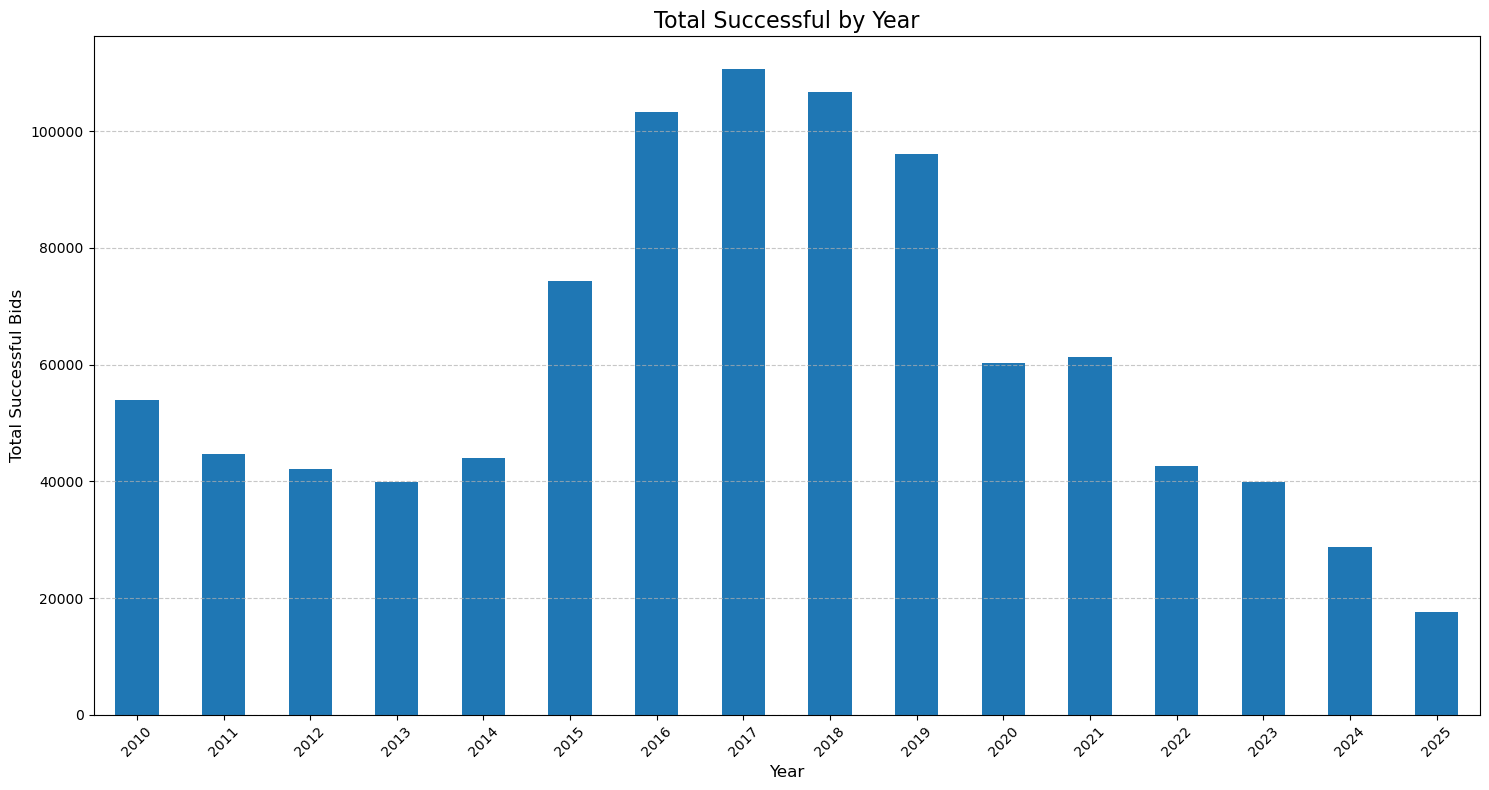

In [65]:
# Create the bar chart directly from the result
plt.figure(figsize=(15, 8))
total_successful_bids_by_year.plot (kind='bar')

# Config bar chart: Set the title and labels
plt.title('Total Successful by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Successful Bids', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# unsurprisingly, with more quotas during the period 2015 to 2021, there was more successful bids during this period of time

In [59]:
# group by year to find out avg premium by year, round to 2 decimal places
avg_premium_by_year = df.groupby('year')['premium'].mean().round(2)
avg_premium_by_year

year
2010    28551.98
2011    42634.92
2012    58262.98
2013    59155.83
2014    53836.76
2015    50368.06
2016    41509.19
2017    39940.79
2018    28366.75
2019    27852.98
2020    29170.46
2021    44297.26
2022    69769.47
2023    86955.59
2024    67148.89
2025    66976.23
Name: premium, dtype: float64

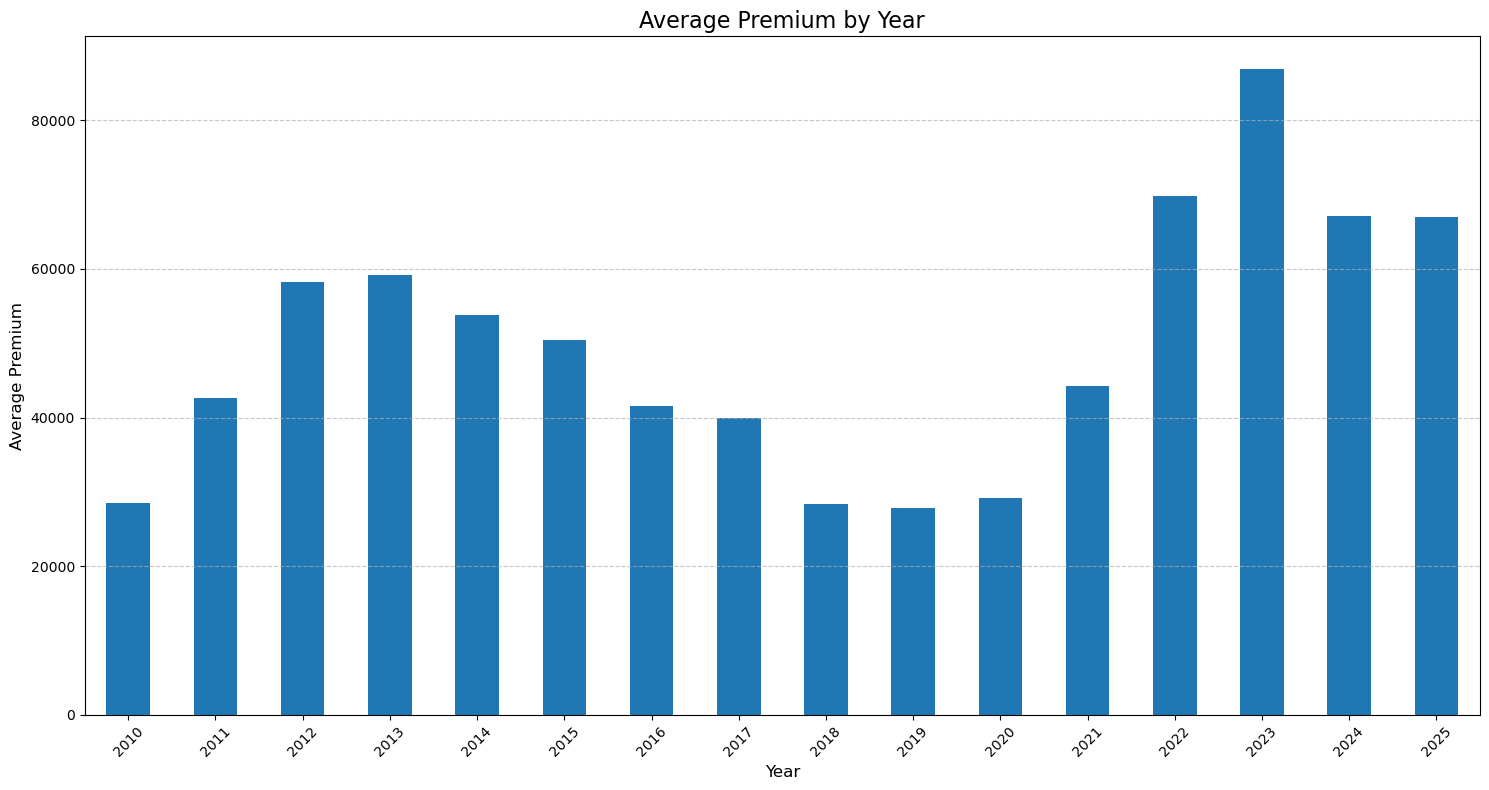

In [67]:
# Create the bar chart directly from the result
plt.figure(figsize=(15, 8))
avg_premium_by_year.plot (kind='bar')

# Config bar chart: Set the title and labels
plt.title('Average Premium by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Premium', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# unsurprisingly, average premiums during the periods of 2015 - 2021 was lower, due mainly to the higher number of quotas
# average premiums during 2020 was also low, when compared against available quotas. This could be because it was covid period

# MACHINE LEARNING AND PREDICTIVE ANALYTICS - LINEAR REGRESSION

## PREDICT TOTAL QUOTA FOR THE MONTH OF SEP 2025

In [91]:
# Group by 'YrMth' and sum the 'quota' to get a single value per month
df_monthly = df.groupby('YrMth')['quota'].sum().reset_index()
df_monthly

,YrMth,quota
0,2010-01-01,5986
1,2010-01-02,5943
2,2010-01-03,5956
3,2010-01-04,4365
4,2010-01-05,4456
...,...,...
180,2025-01-04,1963
181,2025-01-05,2025
182,2025-01-06,2840
183,2025-01-07,2058


In [93]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly['time_index'] = (df_monthly['YrMth'].dt.year - df_monthly['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly['YrMth'].dt.month - df_monthly['YrMth'].dt.month.min())
df_monthly['time_index'] 

0        0
1        0
2        0
3        0
4        0
      ... 
180    180
181    180
182    180
183    180
184    180
Name: time_index, Length: 185, dtype: int32

In [95]:
# Train the linear regression model

# Define the feature (X) and target (y)
X = df_monthly[['time_index']]
y = df_monthly['quota']

In [97]:
# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [99]:
# Predict the quota for September 2025

# Calculate the time_index for September 2025
# The data starts in January 2010 (first month).
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index = np.array([[months_since_start]])

In [101]:
# Make the prediction
predicted_quota = model.predict(sept_2025_index)

print(f"The predicted total quota for September 2025 is: {int(predicted_quota[0])}")

The predicted total quota for September 2025 is: 4928


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## PREDICT PREMIUM FOR THE MONTH OF SEP 2025

In [112]:
# Group by 'YrMth' and sum the 'quota' to get a single value per month
df_monthly_premium = df.groupby('YrMth')['premium'].mean().reset_index().round(2)
df_monthly_premium

,YrMth,premium
0,2010-01-01,16321.30
1,2010-01-02,18077.20
2,2010-01-03,24351.00
3,2010-01-04,31604.70
4,2010-01-05,26854.70
...,...,...
180,2025-01-04,64664.00
181,2025-01-05,63349.00
182,2025-01-06,69769.86
183,2025-01-07,65448.17


In [114]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly_premium['time_index'] = (df_monthly_premium['YrMth'].dt.year - df_monthly_premium['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly_premium['YrMth'].dt.month - df_monthly_premium['YrMth'].dt.month.min())
df_monthly_premium['time_index'] 

0        0
1        0
2        0
3        0
4        0
      ... 
180    180
181    180
182    180
183    180
184    180
Name: time_index, Length: 185, dtype: int32

In [116]:
# Train the linear regression model

# Define the feature (X) and target (y)
X = df_monthly_premium[['time_index']]
y = df_monthly_premium['premium']

In [118]:
# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [120]:
# Predict the quota for September 2025

# Calculate the time_index for September 2025
# The data starts in January 2010 (first month).
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index = np.array([[months_since_start]])

In [122]:
# Make the prediction
predicted_avg_premium = model.predict(sept_2025_index)

print(f"The predicted average premium for September 2025 is: {int(predicted_avg_premium[0])}")

The predicted average premium for September 2025 is: 62973


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## PREDICT PREMIUM FOR vehicle_class = category A FOR THE MONTH OF SEP 2025

In [127]:
# Filter the DataFrame for 'Category A' only
df_category_a = df[df['vehicle_class'] == 'Category A'].copy()

In [131]:
# Convert 'YrMth' to a datetime object
df_category_a['YrMth'] = pd.to_datetime(df_category_a['YrMth'], format='%m/%d/%Y')

In [133]:
# Group by 'YrMth' and take the mean of 'premium' to get a single value per month
df_monthly_a = df_category_a.groupby('YrMth')['premium'].mean().reset_index()

In [135]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly_a['time_index'] = (df_monthly_a['YrMth'].dt.year - df_monthly_a['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly_a['YrMth'].dt.month - df_monthly_a['YrMth'].dt.month.min())

In [137]:
# Train the linear regression model

# Define the feature (X) and target (y)
X_a = df_monthly_a[['time_index']]
y_a = df_monthly_a['premium']

In [139]:
# Initialize and train the linear regression model
model_a = LinearRegression()
model_a.fit(X_a, y_a)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [141]:
# Predict the premium for September 2025

# Calculate the time_index for September 2025
# The data starts in January 2010 (first month).
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index_a = np.array([[months_since_start]])

In [143]:
# Make the prediction
predicted_premium_a = model_a.predict(sept_2025_index_a)

print(f"The predicted premium for Category A in September 2025 is: {int(predicted_premium_a[0])}")

The predicted premium for Category A in September 2025 is: 63529


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# MACHINE LEARNING AND PREDICTIVE ANALYTICS - RANDOM FOREST

## PREDICT TOTAL QUOTA FOR THE MONTH OF SEP 2025

In [154]:
# Convert 'YrMth' to a datetime object
df['YrMth'] = pd.to_datetime(df['YrMth'], format='%m/%d/%Y')

In [156]:
# Group by 'YrMth' and sum the 'quota' to get a single value per month
df_monthly = df.groupby('YrMth')['quota'].sum().reset_index()

In [158]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly['time_index'] = (df_monthly['YrMth'].dt.year - df_monthly['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly['YrMth'].dt.month - df_monthly['YrMth'].dt.month.min())

In [160]:
# 2. Train the Random Forest Regressor model

# Define the feature (X) and target (y)
X = df_monthly[['time_index']]
y = df_monthly['quota']

In [162]:
# Initialize and train the Random Forest Regressor model
# Using 100 estimators and a random state for reproducibility
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [164]:
# 3. Predict the quota for September 2025

# Calculate the time_index for September 2025
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index_rf = np.array([[months_since_start]])

In [166]:
# Make the prediction
predicted_quota_rf = model_rf.predict(sept_2025_index_rf)

print(f"The predicted total quota for September 2025 using Random Forest is: {int(predicted_quota_rf[0])}")

The predicted total quota for September 2025 using Random Forest is: 2248


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## PREDICT PREMIUM FOR THE MONTH OF SEP 2025

In [169]:
# Convert 'YrMth' to a datetime object
df['YrMth'] = pd.to_datetime(df['YrMth'], format='%m/%d/%Y')

In [179]:
# Group by 'YrMth' and sum the 'quota' to get a single value per month
df_monthly = df.groupby('YrMth')['premium'].mean().reset_index()

In [181]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly['time_index'] = (df_monthly['YrMth'].dt.year - df_monthly['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly['YrMth'].dt.month - df_monthly['YrMth'].dt.month.min())

In [185]:
# 2. Train the Random Forest Regressor model

# Define the feature (X) and target (y)
X = df_monthly[['time_index']]
y = df_monthly['premium']

In [187]:
# Initialize and train the Random Forest Regressor model
# Using 100 estimators and a random state for reproducibility
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [189]:
# 3. Predict the quota for September 2025

# Calculate the time_index for September 2025
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index_rf = np.array([[months_since_start]])

In [191]:
# Make the prediction
predicted_premium_rf = model_rf.predict(sept_2025_index_rf)

print(f"The predicted avg premium for September 2025 using Random Forest is: {int(predicted_premium_rf[0])}")

The predicted avg premium for September 2025 using Random Forest is: 67383


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## PREDICT PREMIUM FOR vehicle_class = category A FOR THE MONTH OF SEP 2025

In [195]:
# Filter the DataFrame for 'Category A' only
df_category_a = df[df['vehicle_class'] == 'Category A'].copy()

In [197]:
# Convert 'YrMth' to a datetime object
df_category_a['YrMth'] = pd.to_datetime(df_category_a['YrMth'], format='%m/%d/%Y')

In [199]:
# Group by 'YrMth' and take the mean of 'premium' to get a single value per month
df_monthly_a = df_category_a.groupby('YrMth')['premium'].mean().reset_index()

In [201]:
# Create a numerical 'time_index' feature for the regression model.
# This represents the number of months from the start of the data.
df_monthly_a['time_index'] = (df_monthly_a['YrMth'].dt.year - df_monthly_a['YrMth'].dt.year.min()) * 12 + \
                            (df_monthly_a['YrMth'].dt.month - df_monthly_a['YrMth'].dt.month.min())

In [203]:
# Train the Random Forest Regressor model

# Define the feature (X) and target (y)
X_a = df_monthly_a[['time_index']]
y_a = df_monthly_a['premium']

In [205]:
# Initialize and train the Random Forest Regressor model
# Using 100 estimators and a random state for reproducibility
model_rf_a = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_a.fit(X_a, y_a)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [207]:
# Predict the premium for September 2025

# Calculate the time_index for September 2025
start_date = pd.to_datetime('2010-01-01')
target_date = pd.to_datetime('2025-09-01')
months_since_start = (target_date.year - start_date.year) * 12 + (target_date.month - start_date.month)
sept_2025_index_rf_a = np.array([[months_since_start]])

In [209]:
# Make the prediction
predicted_premium_rf_a = model_rf_a.predict(sept_2025_index_rf_a)

print(f"The predicted premium for Category A in September 2025 using Random Forest is: {int(predicted_premium_rf_a[0])}")

The predicted premium for Category A in September 2025 using Random Forest is: 99375


C:\Users\wjlee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
